26
0.992702


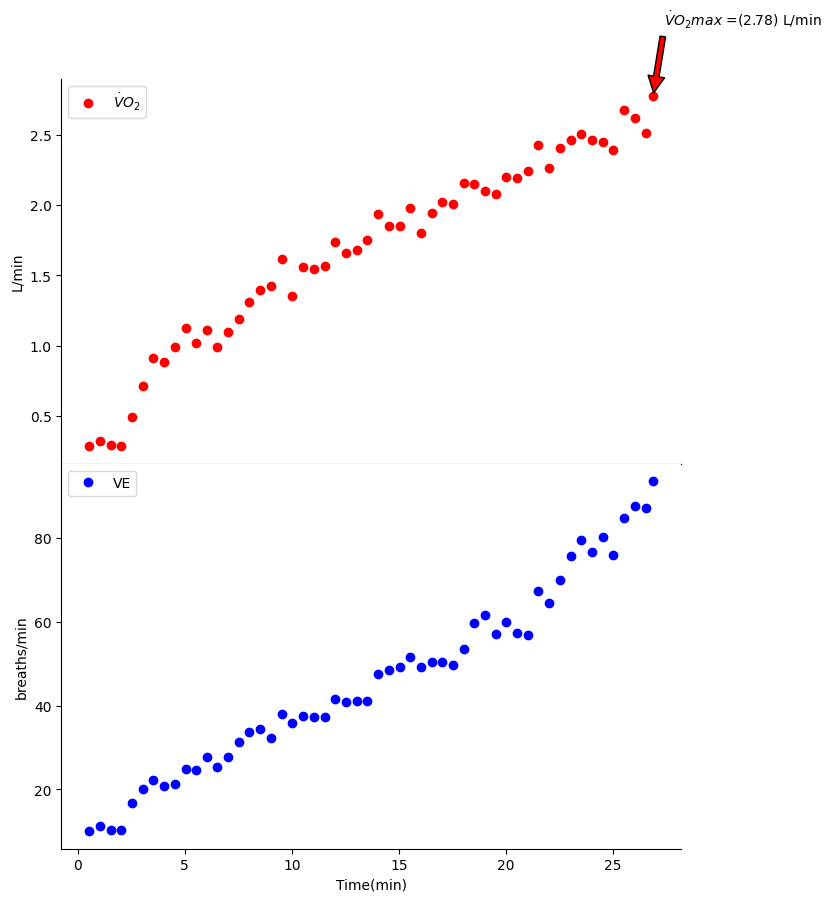

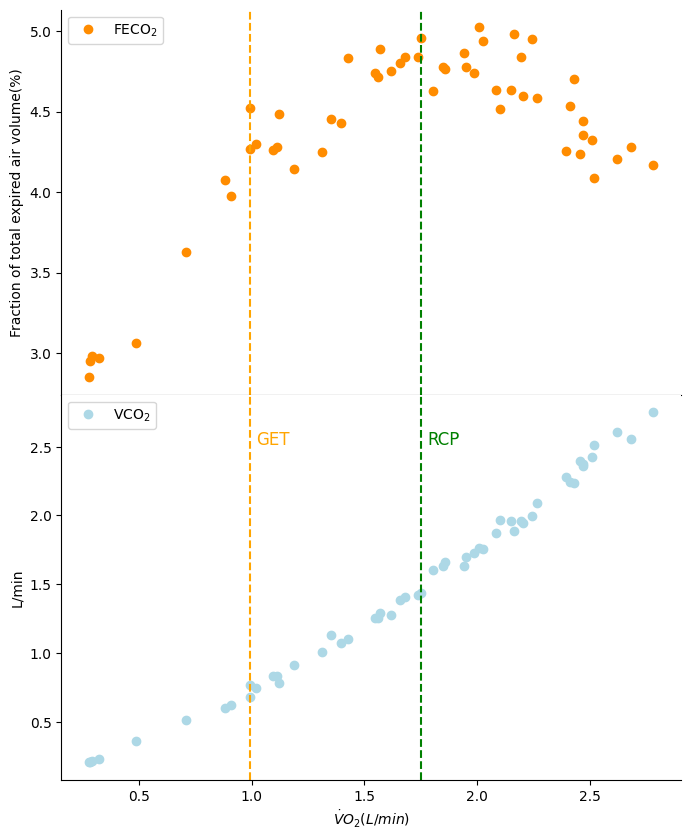

In [3]:
### Now all together in one code block that could run independently...
# lets take care of importing everything we need at once

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os

# Lets read in our file now
df = pd.read_csv('/kaggle/input/datasets/ssamadahmed/dataset/subject_1321.csv', header=[0], skiprows=[1,2,3])

# please note that while this is an output file from the parvo-metabolics cart we have
# I have edited this data set and simplied the header file on it

# rename our column headers
df = df.rename(columns={'VE/': 'VE/VO2','VE/.1': 'VE/VCO2'})

# simplify our terms to reduce future typing... 
# it is easier to write plot x, y than plot df['Time'], df['VO2']
x = df['TIME']
y = df['VO2']
y1 = df['VE']

#Find VO2 max value 
ymax = max(y)

# find the x position of the ymax value or where ymax occurs on the x axis
xmax = x[y.argmax()]

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 10)) # Note I increased the figure size here.

# this line seperates the two plots...
fig.subplots_adjust(hspace=0)

# annotate the position of V02 max before plotting the value, we could do this later but why.

ax[0].annotate('$\\dot VO_2max$ =({}) L/min'.format(round(ymax, 2)), 
               xy=(xmax, ymax), xytext=(xmax+.5, ymax+ .5),
               arrowprops=dict(facecolor='red', shrink= 0.05),
                )

ax[0].plot(x, y, 'o', label=('$\\dot VO_2$'), c='r' )
# in the line of code below I hide the top and right black bars serrounding the plot for APA format.
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].set(ylabel=('L/min'))
ax[0].legend()
#note all these set features could be added in one line but reading it would be difficult

# Second plot of values down from the top
ax[1].plot(x, y1, 'o', label=('VE'), c='b')
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].set(ylabel=('breaths/min'))
ax[1].set(xlabel=('Time(min)'))
ax[1].legend()

# save the figure before we show it... or it will be blank
fig.savefig("VO2-VE-4.png", dpi=300, bbox_inches = "tight")
fig.show()

# Additional gas exchange plots
x2 = df['VO2']
y2 = df['FECO2']
y3 = df['VCO2']

fig2, ax2 = plt.subplots(2, 1, sharex=True, figsize=(8, 10))

# this line seperates the two plots...
fig2.subplots_adjust(hspace=0)

# First plot
ax2[0].plot(x2, y2, 'o', label=('FECO$_2$'), c='darkorange')
ax2[0].spines[['right', 'top']].set_visible(False)
ax2[0].set(ylabel=('Fraction of total expired air volume(%)'))
ax2[0].legend(loc= 'upper left')

# Second plot
ax2[1].plot(x2, y3, 'o', label=('VCO$_2$'), c='lightblue')
ax2[1].spines[['top', 'right']].set_visible(False)
ax2[1].set(ylabel=('L/min'))
ax2[1].set(xlabel=('$\\dot VO_2(L/min)$'))
ax2[1].legend()


# GET(gas exhange threshold) and RCP( Respiratory Compensatory Point)

# GET = lowest VE/VO2
get= df['VE/VO2'].argmin()
get_vo2 = df['VO2'][get] 

# RCP = lowest VE/VCO2 after GET
vevco2_after_get = df['VE/VCO2'][get:]
rcp= vevco2_after_get.argmin()
rcp_vo2 = df['VO2'][rcp]

# Threshold lines on both subplots
ax2[0].axvline(get_vo2, color='orange', linestyle='--', label='GET')
ax2[0].axvline(rcp_vo2, color='g', linestyle='--', label='RCP')
ax2[1].axvline(get_vo2, color='orange', linestyle='--', label='GET')
ax2[1].axvline(rcp_vo2, color='g', linestyle='--', label='RCP')

#Text labels for subplots
ax2[1].text(get_vo2 + 0.1, max(y2) * 0.5, 'GET', color='orange', fontsize=12, ha='center')
ax2[1].text(rcp_vo2 + 0.1, max(y2) * 0.5, 'RCP', color='g', fontsize=12, ha='center')

# save the figure before we show it... or it will be blank
fig2.savefig("FECO2-VCO2-vs-VO2.png", dpi=300, bbox_inches="tight")
fig2.show()

print(rcp)
print(get_vo2)